In [99]:
import os
import sys
import glob
import random
import math
import pathlib
from copy import deepcopy
from collections import namedtuple

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import AutoMinorLocator

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import GlorotUniform, HeNormal
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import (CategoricalAccuracy,
                                      FalseNegatives,
                                      FalsePositives,)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import L1, L2

import nilearn.connectome
from nilearn import image
from nilearn.input_data import NiftiMasker
from nilearn.plotting import plot_anat, plot_matrix, plot_stat_map, show

from sklearn import preprocessing
from sklearn.base import TransformerMixin
from sklearn.metrics import (ConfusionMatrixDisplay,
                             accuracy_score,
                             classification_report,
                             confusion_matrix,
                             f1_score,
                             precision_score,
                             recall_score,)
from sklearn.model_selection import (KFold,
                                     StratifiedKFold,
                                     cross_val_predict,
                                     cross_val_score,
                                     train_test_split,)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

## Fetching Haxby dataset

In this notebook, all the models are trained on the *Haxby et al. (2001) data set* which is a high-quality block-design fMRI dataset from a study on face and object representation in the human ventral temporal cortex (involved in the high-level visual processing of complex stimuli). The data set consisted of 6 subjects and 12 runs for each, but for the tutorial session we fetch just one of the subjects.

The dataset can be download using the following command:
```
haxby_ds = datasets.fetch_haxby(subjects=[sub_no], fetch_stimuli=True, data_dir=data_dir)
```
Also, We can easily remove resting state tasks at the time of selecting the data. That would give us higher accuracy results.
```
X = masker.fit_transform(func_file)[nonrest_task_mask]
y = labels['labels'][nonrest_task_mask]
```
The event design labels in this dataset are the visual stimuli:
- <i>'face', 'chair', 'scissors', 'shoe', 'scrambledpix', 'house', 'cat', 'bottle' and 'rest'</i>

In [ ]:
RANDOM_STATE = 42

SEED = RANDOM_STATE
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = "cuda"
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
else:
    device = "cpu"

if device == "cuda":
    print("GPU found :D Training will be carried out on GPU.")
else:
    print("No GPU found. Training will be carried out on CPU, which might be slower.")

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

No GPU found. Training will be carried out on CPU, which might be slower.


In [ ]:
DATA_DIR = "your_path"
RAW_DATA_DIR = os.path.join(DATA_DIR, "haxby2001", "subj4")
FUNC_FILE = os.path.join(RAW_DATA_DIR, "bold.nii.gz")
SESSION_TARGET = os.path.join(RAW_DATA_DIR, "labels.txt")

# Fetched the data for subject 4
# Standardizing
mask_vt_file = os.path.join(RAW_DATA_DIR, "mask4_vt.nii.gz")
masker = NiftiMasker(mask_img=mask_vt_file, standardize="zscore_sample") # <- standardize=True gives deprecation warning

labels = pd.read_csv(SESSION_TARGET, sep=" ")

# Selecting data
X = masker.fit_transform(FUNC_FILE)
labels = labels["labels"]

/var/folders/n3/nqqvqq1n0jx25dfd3nyxjxmh0000gn/T/ipykernel_81673/15517641.py:9: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(FUNC_FILE)
/var/folders/n3/nqqvqq1n0jx25dfd3nyxjxmh0000gn/T/ipykernel_81673/15517641.py:9: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  X = masker.fit_transform(FUNC_FILE)


## Checking the data
Here we see the shape and the labels (it can be called also features or unique conditions) of this data sample, which is necessary to check before start training any decoding model!

In [4]:
categories = labels.unique()
print(categories)
print(type(X))
print(type(labels))
print(X.shape)
print(labels.shape)

<StringArray>
[        'rest',         'face',        'chair',     'scissors',
         'shoe', 'scrambledpix',        'house',          'cat',
       'bottle']
Length: 9, dtype: str
<class 'numpy.ndarray'>
<class 'pandas.Series'>
(1452, 675)
(1452,)


## Logistic Regression VS One-Layer Perceptron (via Keras)
> PyTorch later in MLP...

Label-encode and one-hot-encode string labels.

In [104]:
le, enc = LabelEncoder(), OneHotEncoder()
le.fit(labels)
print(f"LabelEncoder classes (unique set) = {le.classes_}")
y_labels = le.transform(labels)
print(f"LabelEncoder targets (unique set) = {set(y_labels)}")
y = enc.fit_transform(y_labels[:, np.newaxis]).toarray()
print("\nOneHoteEncoder targets array:")
display(pd.DataFrame(y))

LabelEncoder classes (unique set) = ['bottle' 'cat' 'chair' 'face' 'house' 'rest' 'scissors' 'scrambledpix'
 'shoe']
LabelEncoder targets (unique set) = {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)}

OneHoteEncoder targets array:


,0,1,2,3,4,5,6,7,8
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1447,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1448,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1449,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1450,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### Just LogisticRegression from sklearn, plain and simple...
Honestly, it's already good enough (default arguments, no hyperparameter tuning).

In [112]:
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(X, y_labels,
                                                    test_size=TEST_SIZE,
                                                    shuffle=True,
                                                    stratify=y,
                                                    random_state=RANDOM_STATE)

print(f"train: {len(X_train)} | test: {len(X_test)}\n")


clf = LogisticRegression(solver="lbfgs", max_iter=1000)
clf.fit(X_train, y_train)
print(f"Test accuracy = {clf.score(X_test, y_test)}")

train: 1161 | test: 291

Test accuracy = 0.852233676975945


### One-layer perceptron
- Inherits from `tf.keras.layers.Layer`
    - `MyLinear`: affine map
    - `MySoftmax`: softmax turns logits into probabilities
- Inherits from `tf.keras.Model`
    - `MyModel`: implements a <i>manual</i> training loop `manual_train` using <strong>mini-batch GD (gradient-descent) with L2 normalization</strong>
> Due to class inheritance, `MyModel` is compatible with `tf.keras` native methods like `.compile()`, `.fit()` and `.evaluate()`; not implemented here.

In [ ]:
class MyLinear(tf.keras.layers.Layer):
    def __init__(self, units, l2_coef): # units is output_dim
        super().__init__()
        self.units = units
        self.l2_coef = l2_coef

    def build (self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], self.units),
                                 initializer="he_normal",
                                 regularizer=L2(l2=self.l2_coef),
                                 trainable=True)
        self.b = self.add_weight(shape=(self.units,), initializer="zeros", trainable=True)

    def call(self, inputs): # inputs.shape = (batch_size, input_dim); self.w.shape = (input_dim, units); self.b.shape = (units,)
        return tf.einsum("ji, kj -> ki", self.w, inputs) + self.b # tf.tile(self.b, (inputs.shape[0], 1)) <- this is not needed because tf automatically broadcasts it
        # equivalent: return tf.matmul(inputs, self.w) + self.b

class MySoftmax(tf.keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.units = units
    
    def call(self, inputs):
        exp_inputs = tf.exp(inputs - tf.reduce_max(inputs, axis=-1, keepdims=True)) # for numerical stability
        return exp_inputs / tf.reduce_sum(exp_inputs, axis=-1, keepdims=True)
    
class MyModel(tf.keras.Model):
    def __init__(self, n_features, n_classes, l2_coef, name=None):
        super().__init__(name=name)
        self.linear = MyLinear(units=n_classes, l2_coef=l2_coef)
        self.softmax = MySoftmax(units=n_classes)
        self.l2_coef = l2_coef
        model = tf.keras.Sequential()
        model.add(Input(shape=(n_features, )))
        model.add(self.linear)
        model.add(self.softmax)
        self.model = model

    def call(self, inputs, training=False):
        return self.model(inputs, training=training)

    def manual_train(self, X: np.ndarray, y: np.ndarray,
                     batch_size: int, n_epochs: int, lr: float, shuffle: bool=True):
        """y must be one-hot encoded for cross entropy loss calculation"""
        n_samples = X.shape[0]
        n_batches = math.ceil(n_samples / batch_size)

        X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
        y_tf = tf.convert_to_tensor(y, dtype=tf.float32)  # one-hot
        
        epoch_losses = np.zeros((n_epochs,), dtype=float)
        epoch_accs = np.zeros((n_epochs,), dtype=float)
        for epoch in range(n_epochs):
            if shuffle:
                indices = np.random.permutation(n_samples)
            else:
                indices = np.arange(n_samples)
            batches = np.array_split(indices, n_batches)
            
            running_loss = 0.0
            truths, predictions = [], []
            for batch in batches:
                Xb, yb = tf.gather(X_tf, batch), tf.gather(y_tf, batch)    # shape = (batch_size, n_features)
                mb = tf.cast(tf.shape(Xb)[0], tf.float32)                  # cast to float for dtype alignment in grad_w in grad_b
                truths.append(tf.math.argmax(yb, axis=-1).numpy())         # shape (batch_size, )

                probs = self(Xb)                                            # w and b get initilaized from call()
                predictions.append(tf.math.argmax(probs, axis=-1).numpy())  # shape (batch_size, )
                probs_clip = tf.clip_by_value(probs, 1e-12, 1.0)            # shape = (batch_size, n_classes)

                data_loss = - tf.linalg.trace(tf.transpose(tf.math.log(probs_clip)) @ yb) 
                # equivalent: data_loss = - tf.reduce_sum(tf.math.log(probs_clip) * yb)
                running_loss += float(data_loss.numpy())

                grad_w = (tf.transpose(Xb) @ (probs - yb)) / mb + self.l2_coef * self.linear.w
                self.linear.w.assign_sub(lr * grad_w)
                grad_b = tf.reduce_sum(probs - yb, axis=0) / mb
                self.linear.b.assign_sub(lr * grad_b)
            
            l2_term = 0.5 * self.l2_coef * tf.reduce_sum(tf.square(self.linear.w))
            loss = running_loss / n_samples + float(l2_term.numpy())
            epoch_losses[epoch] = loss
            
            truths = np.concatenate(truths)
            predictions = np.concatenate(predictions)
            # my original, dumber summation: acc = sum([1 for t, p in zip(truths, predictions) if t==p]) / len(truths)
            acc = np.mean(truths == predictions)
            epoch_accs[epoch] = acc
        
        return epoch_losses, epoch_accs
    
    def manual_predict(self, X: np.ndarray, y: np.ndarray):
        X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
        y_tf = tf.convert_to_tensor(y, dtype=tf.float32)  # one-hot
        truths = tf.math.argmax(y_tf, axis=-1).numpy()

        probs = self(X_tf)
        predictions = tf.math.argmax(probs, axis=-1).numpy()
        acc = np.mean(truths == predictions)
        return {"acc": float(acc), "preds": predictions, "labels": truths}


In [101]:
TEST_SIZE = 0.2
L2_COEF = 1e-5
LEARNING_RATE = 0.1 

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=TEST_SIZE,
                                                    shuffle=True,
                                                    stratify=y,
                                                    random_state=RANDOM_STATE)

print(f"train: {len(X_train)} | test: {len(X_test)}\n")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

_, n_features = X.shape
n_classes = len(labels.unique())
one_layer_net = MyModel(n_features, n_classes, l2_coef=L2_COEF)
epoch_losses, epoch_accs = one_layer_net.manual_train(X_train, y_train,
                                                      batch_size=X_train.shape[0], n_epochs=1000,
                                                      lr=LEARNING_RATE, shuffle=True)
res = one_layer_net.manual_predict(X_test, y_test)
print(f"Test accuracy = {res['acc']}")

train: 1161 | test: 291

Test accuracy = 0.8591065292096219


5-fold CV

In [102]:
N_FOLDS = 5

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_accs = []
for i, (train_idx, valid_idx) in enumerate(skf.split(X, enc.inverse_transform(y))):
    print(f"FOLD {1 + i}")     
    scaler = StandardScaler()
    X_train, X_valid = X[train_idx], X[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx] 
    X_train = scaler.fit_transform(X_train)
    X_valid = scaler.transform(X_valid)
    
    one_layer_net = MyModel(n_features, n_classes, l2_coef=L2_COEF)  # re-instantiate a fresh model 
    one_layer_net.manual_train(X_train, y_train,
                               batch_size=X_train.shape[0], n_epochs=1000,
                               lr=LEARNING_RATE, shuffle=True)
    fold_accs.append(one_layer_net.manual_predict(X_valid, y_valid)["acc"])

print(f"\nFold accuracies: {fold_accs}\n  >> mean = {np.mean(fold_accs)}; std = {np.std(fold_accs)}")

FOLD 1
FOLD 2
FOLD 3
FOLD 4
FOLD 5

Fold accuracies: [0.8556701030927835, 0.8350515463917526, 0.8172413793103448, 0.8551724137931035, 0.8379310344827586]
  >> mean = 0.8402132954141486; std = 0.014298597299730119


We can also try other model classes like a support vector machine classifier or a random foreset.
## Suppport Vector Machine (One-Vs-Rest Extension for Multi-Class)

## Random Forest

## MLP (Multiple-Layer Perceptron) in TensorFlow Keras
Keras actually obscures away a lot of the training loop and optimization tracking...

In [19]:
LEARNING_RATE = 1e-3
L2_COEF = 1e-4
DROPOUT = 0.1
WEIGHT_DECAY = 1e-5

TEST_SIZE = 0.15
INNER_VALID_SIZE = 0.1765
# -> train : valid : test = 70% : 15% : 15%

N_FOLDS =5
BATCH_SIZE, N_EPOCHS = 128, 50
MIN_DELTA, PATIENCE = 1e-4, 5

def build_model(n_features: int, n_classes: int, units: tuple | None=None, name: str | None=None):
    if units is None:
        units = (16, 8)
    model = tf.keras.Sequential(name=name)
    model.add(Input(shape=(n_features, )))
# You can also omit the initial `Input`, i.e., the model doesn't have any weights until the first call
# Note that when using the delayed-build pattern (no input shape specified),
# the model gets built the first time you call `fit`, `eval`, or `predict`,
# or the first time you call the model on some input data.

# z = ReLu(w.T @ x + b)
    model.add(
        Dense(units[0],
            activation="relu", 
            kernel_initializer=HeNormal(seed=RANDOM_STATE), # w initialization
            bias_initializer="zeros", # b initialization
            kernel_regularizer=L2(l2=L2_COEF))
    ) 
    model.add(
        Dropout(DROPOUT, seed=RANDOM_STATE)
    )
    model.add(
        Dense(units[1],
            activation="relu", 
            kernel_initializer=HeNormal(seed=RANDOM_STATE),
            bias_initializer="zeros",
            kernel_regularizer=L2(l2=L2_COEF))
    )
    model.add(
        Dense(n_classes,
            activation="softmax", 
            use_bias=True,
            kernel_initializer=GlorotUniform(seed=RANDOM_STATE), 
            bias_initializer="zeros")
    )

    model.compile(
            optimizer=Adam(learning_rate=LEARNING_RATE),
            loss=CategoricalCrossentropy(), # requires one-hot encoded labels (targets)
            metrics=[
                CategoricalAccuracy(),
            ],
            run_eagerly=False,
    )
    return model

n_samples, n_features = X.shape
n_classes = len(labels.unique())


model = build_model(n_features, n_classes, units=(16, 8), name="fMRI_clf")
print(f"Sequential() instance is of type `{type(model)}`")
display(model.summary())
print(model.metrics_names)

Sequential() instance is of type `<class 'keras.src.models.sequential.Sequential'>`


Model: "fMRI_clf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        10,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,033 (43.10 KB)

 Trainable params: 11,033 (43.10 KB)

 Non-trainable params: 0 (0.00 B)

None

['loss', 'compile_metrics']


### Nested validation for early stopping with fixed hyperparameters (short-cut, no fresh model re-instantiation and re-fitting before validation in outer loop)
- Split dataset via sklearn `train_test_split()`
    - $D \rightarrow D_{train \: outer} \cup D_{test}$. Do not touch $D_{test}$ until final performance evaluation
- <strong>Outer 5-fold CV</strong> via sklearn `StratifiedKFold()`. For each fold:
    - $D_{train \: outer} \rightarrow D_{fit} \cup D_{valid \: outer}$
    - <strong>Fixed held-out inner validation set</strong> split $D_{fit} \rightarrow D_{train \: inner} \cup D_{valid \: inner}$ via sklearn `train_test_split()`
    > Note that "fixed" means the held-out validation set is fixed <i>within that fold</i>, not globally fixed once (since there's an outer 5-fold CV loop)
    - Train on `(X_train_inner, y_train_inner)` and validate on `(X_valid_inner, y_valid_inner)` until validation loss stops improving for PATIENCE = 5 epochs then early stop, otherwise train until N_EPOCHS = 50.
    - `Keras` automatically restores the model to its best epoch state (before validation loss stopped improving); take the best-state-restored model and validate on `(X_valid_outer, y_valid_outer)`.

In [23]:
X_train_outer, X_test, y_train_outer, y_test = train_test_split(X, y,
                                                    test_size=TEST_SIZE,
                                                    shuffle=True,
                                                    stratify=y,
                                                    random_state=RANDOM_STATE)

print(f"train_outer: {len(X_train_outer)} | test: {len(X_test)}\n")

history_lst, cv_scores = [], []
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
for i, (fit_idx, valid_idx) in enumerate(skf.split(X_train_outer, enc.inverse_transform(y_train_outer))):
    print(f"FOLD {1 + i}")     
    X_fit, X_valid_outer = X_train_outer[fit_idx], X_train_outer[valid_idx]
    y_fit, y_valid_outer = y_train_outer[fit_idx], y_train_outer[valid_idx] 

    scaler = StandardScaler()
    X_train_inner, X_valid_inner, y_train_inner, y_valid_inner = train_test_split(X_fit, y_fit,
                                                    test_size=INNER_VALID_SIZE,
                                                    shuffle=True,
                                                    stratify=enc.inverse_transform(y_fit),
                                                    random_state=RANDOM_STATE)
    X_train_inner = scaler.fit_transform(X_train_inner)
    X_valid_inner = scaler.transform(X_valid_inner)
    
    model = build_model(n_features, n_classes, units=(256, 128), name="fMRI_clf")
    history = model.fit(X_train_inner, y_train_inner,
        batch_size=BATCH_SIZE,
        epochs=N_EPOCHS,
        validation_data=(X_valid_inner, y_valid_inner),
        callbacks=[EarlyStopping(
            monitor="val_loss",
            min_delta=MIN_DELTA,
            patience=PATIENCE,
            mode="min",
            baseline=None,
            restore_best_weights=True,
            start_from_epoch=0,
            verbose=1
        )],
        verbose=0)
    history_lst.append(history)

    X_valid_outer = scaler.transform(X_valid_outer)
    score = model.evaluate(
                X_valid_outer, y_valid_outer,
                batch_size=BATCH_SIZE,
                verbose=0,
                return_dict=True,
            )
    cv_scores.append(score)

print("\nCV scores across folds:")
for i, score in enumerate(cv_scores):
    print(f"FOLD {1 + i} : loss = {score['loss']} | accuracy = {score['categorical_accuracy']}")

train_outer: 1234 | test: 218

FOLD 1
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 22.
FOLD 2
Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 14.
FOLD 3
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 9.
FOLD 4
Epoch 12: early stopping
Restoring model weights from the end of the best epoch: 7.
FOLD 5
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 13.

CV scores across folds:
FOLD 1 : loss = 0.8269026875495911 | accuracy = 0.8097165822982788
FOLD 2 : loss = 0.7248060703277588 | accuracy = 0.8016194105148315
FOLD 3 : loss = 0.6245748400688171 | accuracy = 0.829959511756897
FOLD 4 : loss = 0.9468880295753479 | accuracy = 0.7692307829856873
FOLD 5 : loss = 0.7231784462928772 | accuracy = 0.8414633870124817


In [25]:
# for each fold, we can also inspect the training history object
# to see how the loss and accuracy evolved across epochs for both the training and validation sets
print(history_lst[0].history.keys())

dict_keys(['categorical_accuracy', 'loss', 'val_categorical_accuracy', 'val_loss'])


## MLP (Multiple-Layer Perceptron) in PyTorch

### Model and Dataset class initialization
- Custom `Dataset`
- Build model from `nn.Sequential()`
- Define per-epoch train/valid/predict mode functions

In [108]:
N_FOLDS =5
BATCH_SIZE, N_EPOCHS = 128, 50
MIN_DELTA, PATIENCE = 1e-4, 5
LEARNING_RATE = 1e-3
L2_COEF = 1e-4
DROPOUT = 0.1
WEIGHT_DECAY = 1e-5

class MyDataset(Dataset):
    def __init__(self, X, y): 
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def build_torch_mlp(n_features: int, n_classes: int, hidden_dims: tuple,
                    dropout: float=0.1):
    """input shape = (batch_size, n_features)"""    
    model = nn.Sequential(
        nn.Linear(n_features, hidden_dims[0], device=device), # in shape = (batch_size, n_features)
        nn.ReLU(),
        nn.Dropout(p=dropout),
        nn.Linear(hidden_dims[0], hidden_dims[1], device=device),
        nn.ReLU(),
        nn.Linear(hidden_dims[1], n_classes, device=device), # out shape = (batch_size, n_classes)
    )
    return model

loss_fn = nn.CrossEntropyLoss()

def train_mode(dataloader, model, optimizer):
    model.train()

    running_loss, n_samples = 0.0, 0
    preds, ys = [], []
    for Xb, yb in dataloader:
        n_samples += Xb.size(0)
        Xb, yb = Xb.to(device), yb.to(device)
        
        optimizer.zero_grad(set_to_none=True)
        logits = model(Xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        
        batch_loss = Xb.size(0) * loss.item()
        running_loss += batch_loss
        preds.append(logits.argmax(dim=1).detach().cpu().numpy())
        ys.append(yb.detach().cpu().numpy())
    
    epoch_loss = running_loss / n_samples
    preds = np.concatenate(preds)
    ys = np.concatenate(ys)
    epoch_acc = accuracy_score(ys, preds)
    return epoch_loss, epoch_acc

def valid_mode(dataloader, model):
    model.eval()
    
    running_loss, n_samples = 0.0, 0
    preds, ys = [], []
    with torch.inference_mode():
        for Xb, yb in dataloader:
            n_samples += Xb.size(0)
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            loss = loss_fn(logits, yb)
            batch_loss = Xb.size(0) * loss.item()
            running_loss += batch_loss
            preds.append(logits.argmax(dim=1).detach().cpu().numpy())
            ys.append(yb.detach().cpu().numpy())

    epoch_loss = running_loss / n_samples
    preds = np.concatenate(preds)
    ys = np.concatenate(ys)
    epoch_acc = accuracy_score(ys, preds)
    return epoch_loss, epoch_acc

def predict_mode(dataloader, model):
    model.eval()
    ys, preds = [], []
    with torch.inference_mode():
        for Xb, yb in dataloader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            ys.append(yb.detach().cpu().numpy())
            preds.append(logits.argmax(dim=1).detach().cpu().numpy())
    ys = np.concatenate(ys)
    preds = np.concatenate(preds)
    return ys, preds


Re-split dataset using sklearn `train_test_split()`

In [109]:
TEST_SIZE = 0.15
INNER_VALID_SIZE = 0.1765
# -> train : valid : test = 70% : 15% : 15%

n_features, n_classes = X.shape[1], labels.nunique()
y = LabelEncoder().fit_transform(labels) # pytorch takes labels, not one hot encoded arrays
X_train_outer, X_test, y_train_outer, y_test = train_test_split(X, y,
                                                    test_size=TEST_SIZE,
                                                    shuffle=True,
                                                    stratify=y,
                                                    random_state=RANDOM_STATE)

### Nested validation for early stopping with fixed hyperparameters (more <i>"model-selection flavored"</i> -- fresh model re-instantiated and re-fitted before validation in outer loop)
- Split dataset via sklearn `train_test_split()`
    - $D \rightarrow D_{train \: outer} \cup D_{test}$. Do not touch $D_{test}$ until final performance evaluation
- <strong>Outer 5-fold CV</strong> via sklearn `StratifiedKFold()`. For each fold:
    - $D_{train \: outer} \rightarrow D_{fit} \cup D_{valid \: outer}$
    - <strong>Fixed held-out inner validation set</strong> split $D_{fit} \rightarrow D_{train \: inner} \cup D_{valid \: inner}$ via sklearn `train_test_split()`
    > Note that "fixed" means the held-out validation set is fixed <i>within that fold</i>, not globally fixed once (since there's an outer 5-fold CV loop)
    - Train on `(X_train_inner, y_train_inner)` and validate on `(X_valid_inner, y_valid_inner)` until validation loss stops improving for PATIENCE = 5 epochs then early stop, otherwise train until N_EPOCHS = 50.
    - <strong>Re-instantiate</strong> a fresh model and train on `(X_fit, y_fit)` for the number of epochs at which validation loss stopped improving (`best_epoch`)
    - Validate on `(X_valid_outer, y_valid_outer)`
- Final test set evaluation:
    - Re-instantiate a fresh model and train on `(X_train_outer, y_train_outer)` for the median of `best_epoch` over 5 folds
    - Evaluate on `(X_test, y_test)`


In [110]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results, history_arr = np.empty((N_FOLDS, ), dtype=object), np.empty((N_FOLDS, ), dtype=object)
for i, (fit_idx, valid_idx) in enumerate(skf.split(X_train_outer, y_train_outer)):
    print(f"FOLD {1 + i}")  
    X_fit, X_valid_outer = X_train_outer[fit_idx], X_train_outer[valid_idx]
    y_fit, y_valid_outer = y_train_outer[fit_idx], y_train_outer[valid_idx] 

    scaler = StandardScaler()
    X_train_inner, X_valid_inner, y_train_inner, y_valid_inner = train_test_split(X_fit, y_fit,
                                                    test_size=INNER_VALID_SIZE,
                                                    shuffle=True,
                                                    stratify=y_fit,
                                                    random_state=RANDOM_STATE)
    X_train_inner = scaler.fit_transform(X_train_inner)
    X_valid_inner = scaler.transform(X_valid_inner)
    
    train_inner = MyDataset(X_train_inner, y_train_inner)
    train_inner_loader = DataLoader(train_inner, batch_size=BATCH_SIZE, shuffle=True)
    valid_inner = MyDataset(X_valid_inner, y_valid_inner)
    valid_inner_loader = DataLoader(valid_inner, batch_size=BATCH_SIZE, shuffle=False)

    model = build_torch_mlp(n_features, n_classes, hidden_dims=(256, 128), dropout=DROPOUT) 
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
    history = {"train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": []}
    best_loss, best_epoch, no_improve, best_state = float("inf"), 0, 0, None
    for epoch in range(1, N_EPOCHS+1):
        loss_train_inner, acc_train_inner = train_mode(train_inner_loader, model, optimizer)
        loss_valid_inner, acc_valid_inner = valid_mode(valid_inner_loader, model)
        history["train_loss"].append(loss_train_inner)
        history["valid_loss"].append(loss_valid_inner)
        history["train_acc"].append(acc_train_inner)
        history["valid_acc"].append(acc_valid_inner)
        
        if loss_valid_inner < best_loss - MIN_DELTA:
            best_loss = loss_valid_inner
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f"  >> early stopping at epoch {epoch}")
                break      
    history["best_epoch"] = best_epoch
    history["best_state"] = best_state
    history_arr[i] = history
    
    scaler = StandardScaler()

    X_fit = scaler.fit_transform(X_fit)
    fit_data = MyDataset(X_fit, y_fit)
    fit_loader = DataLoader(fit_data, batch_size=BATCH_SIZE, shuffle=True)

    X_valid_outer = scaler.transform(X_valid_outer)
    valid_outer = MyDataset(X_valid_outer, y_valid_outer)
    valid_outer_loader = DataLoader(valid_outer, batch_size=BATCH_SIZE, shuffle=False)

    # instantiate fresh model for cv refit
    model = build_torch_mlp(n_features, n_classes, hidden_dims=(256, 128), dropout=DROPOUT) 
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    for _ in range(best_epoch):
        train_mode(fit_loader, model, optimizer)
    loss_outer, acc_outer = valid_mode(valid_outer_loader, model)
    cv_results[i] = (loss_outer, acc_outer)

FOLD 1
  >> early stopping at epoch 19
FOLD 2
  >> early stopping at epoch 23
FOLD 3
  >> early stopping at epoch 23
FOLD 4
  >> early stopping at epoch 20
FOLD 5
  >> early stopping at epoch 17


In [111]:
best_epochs = [history_arr[i]["best_epoch"] for i in range(len(history_arr))]
max_epochs = int(np.median(best_epochs))

scaler = StandardScaler()

X_train_outer = scaler.fit_transform(X_train_outer)
train_outer_data = MyDataset(X_train_outer, y_train_outer)
train_outer_loader = DataLoader(train_outer_data, batch_size=BATCH_SIZE, shuffle=True)
X_test = scaler.transform(X_test)
test_data = MyDataset(X_test, y_test)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

model = build_torch_mlp(n_features, n_classes, hidden_dims=(256, 128), dropout=DROPOUT) 
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
for _ in range(max_epochs):
    train_mode(train_outer_loader, model, optimizer)

truths, final_preds = predict_mode(test_loader, model)
test_loss, test_acc = valid_mode(test_loader, model)
print(f">> Final refit accuracy on test set: {test_acc}")

>> Final refit accuracy on test set: 0.8669724770642202


Plot the training/validation accuracy and loss curve for each fold (line oppacity `alpha=0.45`), with the fold mean accuracy and loss layered on top (line oppacity `alpha=1.0`)

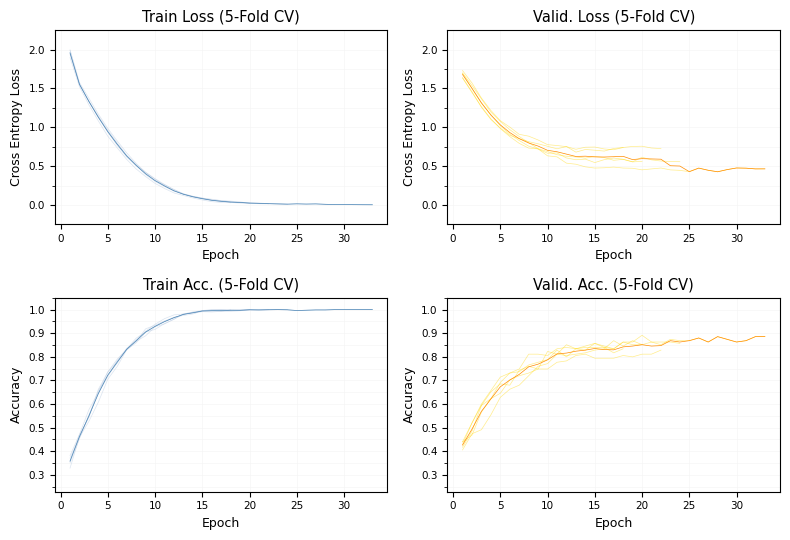

In [8]:
lengths = [len(history_arr[i]["train_loss"]) for i in range(len(best_epochs))]
max_epochs = max(lengths)
folds_train_loss = [history_arr[i]["train_loss"] + [np.nan] * (max_epochs - lengths[i])
                                                            for i in range(len(best_epochs))]
folds_train_acc = [history_arr[i]["train_acc"] + [np.nan] * (max_epochs - lengths[i])
                                                            for i in range(len(best_epochs))]
folds_valid_loss = [history_arr[i]["valid_loss"] + [np.nan] * (max_epochs - lengths[i])
                                                            for i in range(len(best_epochs))]
folds_valid_acc = [history_arr[i]["valid_acc"] + [np.nan] * (max_epochs - lengths[i])
                                                            for i in range(len(best_epochs))]

acc_min = min(np.nanmin(np.concatenate(folds_train_acc)), np.nanmin(np.concatenate(folds_valid_acc)))
loss_min = min(np.nanmin(np.concatenate(folds_train_loss)), np.nanmin(np.concatenate(folds_valid_loss)))
loss_max = max(np.nanmax(np.concatenate(folds_train_loss)), np.nanmax(np.concatenate(folds_valid_loss)))

epochs = np.arange(1, max_epochs+1)
fig, axes = plt.subplots(2, 2, figsize=(8, 5.5), sharey=False)
axes_ = axes.T.flatten()[:2]
for ax, metrics in zip(axes_, [folds_train_loss, folds_train_acc]):
    mean_m = np.nanmean(metrics, axis=0)
    for m in metrics:
        ax.set_axisbelow(True)
        ax.plot(epochs, m, linewidth=0.5, alpha=0.45, color="lightsteelblue")
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.grid(linewidth=0.5, color="whitesmoke", which="major", zorder=1)
        ax.grid(linewidth=0.5, color="whitesmoke", which="minor", zorder=0)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.plot(epochs, mean_m, linewidth=0.5, color="steelblue")
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(axis="both", which="major", labelsize=7.5)
    ax.set_xlabel("Epoch", fontsize=9)
axes_[0].set_ylim(ymin=loss_min-0.25, ymax=loss_max+0.25)
axes_[0].set_ylabel("Cross Entropy Loss", fontsize=9)
axes_[0].set_title("Train Loss (5-Fold CV)", fontsize=10.5)
axes_[1].set_ylim(ymin=acc_min-0.1, ymax=1.05)
axes_[1].set_ylabel("Accuracy", fontsize=9)
axes_[1].set_title("Train Acc. (5-Fold CV)", fontsize=10.5)

axes_ = axes.T.flatten()[2:]
for ax, metrics in zip(axes_, [folds_valid_loss, folds_valid_acc]):
    mean_m = np.nanmean(metrics, axis=0)
    for m in metrics:
        ax.set_axisbelow(True)
        ax.plot(epochs, m, linewidth=0.5, alpha=0.45, color="gold")
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.grid(linewidth=0.5, color="whitesmoke", which="major", zorder=1)
        ax.grid(linewidth=0.5, color="whitesmoke", which="minor", zorder=0)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.plot(epochs, mean_m, linewidth=0.5, color="darkorange")
    ax.tick_params(axis="both", which="major", labelsize=7.5)
    ax.set_xlabel("Epoch", fontsize=9)
axes_[0].set_ylim(ymin=loss_min-0.25, ymax=loss_max+0.25)
axes_[0].set_ylabel("Cross Entropy Loss", fontsize=9)
axes_[0].set_title("Valid. Loss (5-Fold CV)", fontsize=10.5)
axes_[1].set_ylim(ymin=acc_min-0.1, ymax=1.05)
axes_[1].set_ylabel("Accuracy", fontsize=9)
axes_[1].set_title("Valid. Acc. (5-Fold CV)", fontsize=10.5)

fig.tight_layout()
plt.show()


In [9]:
print(labels.value_counts())

labels
rest            588
face            108
chair           108
scissors        108
shoe            108
scrambledpix    108
house           108
cat             108
bottle          108
Name: count, dtype: int64


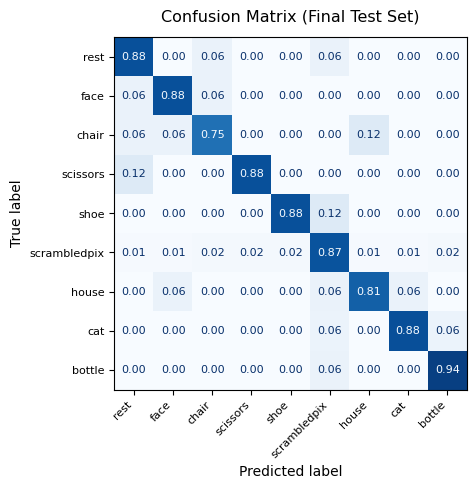

Accuracy = 0.8623853211009175
Precision (weighted) = 0.8663557003028447
          (macro) = 0.8351409594345734
Recall (weighted) = 0.8623853211009175
       (macro) = 0.8608357200558125
F1 Score (weighted) = 0.8632084914963717
         (macro) = 0.8632084914963717


In [10]:
white_blue = LinearSegmentedColormap.from_list(
    "white_blue",
    ["#ffffff", "#dbeafe", "#60a5fa", "#1d4ed8"]
)

cm = confusion_matrix(truths, final_preds, normalize="true")

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.unique())
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
    im_kw={"vmin": 0, "vmax": 1}
)
for text in ax.texts:
    text.set_fontsize(8)

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.title("Confusion Matrix (Final Test Set)", fontsize=11.5, y=1.02)
plt.tight_layout()
plt.show()

print(f"""Accuracy = {test_acc}
Precision (weighted) = {precision_score(truths, final_preds, average="weighted")}
          (macro) = {precision_score(truths, final_preds, average="macro")}
Recall (weighted) = {recall_score(truths, final_preds, average="weighted")}
       (macro) = {recall_score(truths, final_preds, average="macro")}
F1 Score (weighted) = {f1_score(truths, final_preds, average="weighted")}
         (macro) = {f1_score(truths, final_preds, average="weighted")}""")

### Nested CV (Cross-Validation) Hyperparameter-Tuning
Here we manually tune dropout, learning rate, and weight decay.

- Split dataset via sklearn `train_test_split()`
    - $D \rightarrow D_{train \: outer} \cup D_{test}$. Do not touch $D_{test}$ until final performance evaluation.
- <strong>Outer loop 5-fold CV</strong> via sklearn `StratifiedKFold()`. For each fold:
    - $D_{train \: outer} \rightarrow D_{fit} \cup D_{valid \: outer}$
    - <strong>Inner loop 5-fold CV</strong> via sklearn `StratifiedKFold()`. For each set of hyperparameters and for each fold:
        - Split $D_{fit} \rightarrow D_{train \: inner} \cup D_{valid \: inner}, \:\:\: |D_{fit}| : |D_{train \: inner}| = 4: 1$
        - Train on `(X_train_inner, y_train_inner)` and validate on `(X_valid_inner, y_valid_inner)` until <strong>validation loss</strong> stops improving for PATIENCE = 5 epochs then early stop, otherwise train until N_EPOCHS = 50.
        - Restore model state to best state (before validation loss stopped improving), then evaluate <strong>accuracy</strong> on `(X_valid_inner, y_valid_inner)` .
    - Average the accuracy scores across inner loop folds. Select the set of hyperparameters with the highest mean fold accuracy.
    - Re-instantiate a fresh model with the selected best hyperparameters and train on `(X_fit, y_fit)` for the median of `best_epoch` values over the 5 inner loop folds.
    - Validate on `(X_valid_outer, y_valid_outer)` and record the loss and accuracy.
- Final test set evaluation:
    - To select the appropriate set of hyperparameters, there are two options:
        - If one set of hyperparameters is clearly dominant, i.e., all / almost all outer CV folds' best hyperpameter sets are identical, then choose that set.
        - For each set of hyperparameters, average the accuracy over <i>the entire training procedure</i>, i.e., over all the inner loop folds across the 5 outer loop folds (mean of $5 \times 5 = 25$ accuracy scores), then select the set with the highest aggregated mean accuracy.
        > Note that the former may be more of a heuristic shortcut, whereas the latter is statistically more rigorous since hyperparameter selection is then <i>based on inner fold (i.e., the tuning stage) statistics only.</i>
    - Re-instantiate a fresh model with the selected hyperparamters and train on `(X_train_outer, y_train_outer)` for the median of `best_epoch` values (for that hyperparameter set) over <i>the entire training procedure</i> (median of $5 \times 5 = 25$ `best_epoch` values).
    - Evaluate on `(X_test, y_test)` and create a final report.
    
       > The outer CV loop is used to assess performance stability within the training portion and avoid tuning on a single split, while the held-out test set $D_{test}$ is reserved for final un-touched evaluation.



In [11]:
InnerCVWrapper = namedtuple("InnerCVWrapper", ["best_params", "best_idx", "best_fold_acc", "cv_results"])

def initiate_preprocesser(preprocesser_name: str):
    if preprocesser_name == "standard":
        return StandardScaler()

def tune_hyperparams(X_fit: np.ndarray, y_fit: np.ndarray, *,
                     n_features: int, n_classes: int,
                     hidden_dims: tuple,
                     preprocesser_name: str, 
                     dropout_space: list | np.ndarray,
                     lr_space: list | np.ndarray,
                     weight_decay_space: list | np.ndarray,
                     n_folds: int=5,
                     verbose=False) -> InnerCVWrapper:
    
    params = [(dp, lr, wd) for dp in dropout_space for lr in lr_space for wd in weight_decay_space]
    fold_accs_arr = np.empty((len(params), ), dtype=float)
    
    cv_results = np.empty((len(params), ), dtype=object)
    for i, (dp, lr, wd) in enumerate(params):
        cv_results[i] = {}
        cv_results[i]["params_set"] = {"dropout": dp,
                                       "lr": lr,
                                       "weight_decay": wd}
        if verbose:
            print(f"**HYPERPARAMS SET {i + 1}**")

        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)     
        best_epochs, best_losses, acc_valid_list  = [], [], []

        for j, (train_inner_idx, valid_inner_idx) in enumerate(skf.split(X_fit, y_fit)):
            if verbose:
                print(f"FOLD {1 + j}")  
            X_train_inner, X_valid_inner = X_fit[train_inner_idx], X_fit[valid_inner_idx]
            y_train_inner, y_valid_inner = y_fit[train_inner_idx], y_fit[valid_inner_idx] 

            preprocesser = initiate_preprocesser(preprocesser_name)
            X_train_inner = preprocesser.fit_transform(X_train_inner)
            train_inner_data = MyDataset(X_train_inner, y_train_inner)
            train_inner_loader = DataLoader(train_inner_data, batch_size=BATCH_SIZE, shuffle=True)

            X_valid_inner = preprocesser.transform(X_valid_inner)
            valid_inner_data = MyDataset(X_valid_inner, y_valid_inner)
            valid_inner_loader = DataLoader(valid_inner_data, batch_size=BATCH_SIZE, shuffle=False)

            model = build_torch_mlp(n_features, n_classes, hidden_dims=hidden_dims, dropout=dp) 
            weight_params = [p for name, p in model.named_parameters() if "weight" in name]
            bias_params = [p for name, p in model.named_parameters() if "bias" in name]
            optimizer = torch.optim.AdamW([{"params": weight_params,
                                            "weight_decay": wd},
                                            {"params": bias_params,
                                             "weight_decay": 0.0}], lr=lr) # exclude bias params from weight decay
            
            best_loss, best_epoch, no_improve, best_state = float("inf"), 0, 0, None
            for epoch in range(1, N_EPOCHS+1):
                loss_train_inner, _ = train_mode(train_inner_loader, model, optimizer)
                loss_valid_inner, _ = valid_mode(valid_inner_loader, model)

                if loss_valid_inner < best_loss - MIN_DELTA:
                    best_loss = loss_valid_inner
                    best_epoch = epoch
                    best_state = deepcopy(model.state_dict())
                    no_improve = 0
                else:
                    no_improve += 1
                    if no_improve >= PATIENCE:
                        if verbose:
                            print(f"  >> early stopping at epoch {epoch}")
                        break  

            if best_state is not None:
                best_losses.append(best_loss)
                model.load_state_dict(best_state)
                _, acc_valid_inner = valid_mode(valid_inner_loader, model)
                acc_valid_list.append(acc_valid_inner)
                best_epochs.append(best_epoch)
            else:
                raise RuntimeError(f"""best_state is None for hyperparams dropout={dp}, lr={lr}, wd={wd}.
                                   Validation loss may have been NaN or training never updated.""")

        fold_accs_arr[i] = np.mean(acc_valid_list)  
        
        cv_results[i]["best_losses"] = best_losses
        cv_results[i]["fold_accs"] = acc_valid_list
        cv_results[i]["mean_fold_acc"] = fold_accs_arr[i]
        cv_results[i]["best_epochs"] = best_epochs

    best_idx = np.argmax(fold_accs_arr)

    inner_cv_wrapper = InnerCVWrapper(params[best_idx], best_idx, np.max(fold_accs_arr), cv_results)
    return inner_cv_wrapper
    

In [12]:
def nested_cv(X_train_outer: np.ndarray, y_train_outer: np.ndarray, *,
              n_features: int, n_classes: int,
              hidden_dims: tuple,
              n_outer_folds: int, n_inner_folds: int,
              verbose=False, **tune_hyperparams_kwargs) -> tuple:
    
    preprocesser_name = tune_hyperparams_kwargs.get("preprocesser_name", "standard")
    dropout_space = tune_hyperparams_kwargs.get("dropout_space", [0.1, 0.2, 0.3])
    lr_space = tune_hyperparams_kwargs.get("lr_space", [1e-3, 1e-4, 1e-5])
    weight_decay_space = tune_hyperparams_kwargs.get("weight_decay_space", [1e-4, 1e-5, 0])
    
    skf = StratifiedKFold(n_splits=n_outer_folds, shuffle=True, random_state=RANDOM_STATE)    

    inner_cv_wrappers_arr = np.empty((n_outer_folds, ), dtype=object)
    outer_cv_results_arr = np.empty((n_outer_folds, ), dtype=object)
    for j, (fit_idx, valid_outer_idx) in enumerate(skf.split(X_train_outer, y_train_outer)):
        if verbose:
            print(f"FOLD {1 + j}")  
        X_fit, X_valid_outer = X_train_outer[fit_idx], X_train_outer[valid_outer_idx]
        y_fit, y_valid_outer = y_train_outer[fit_idx], y_train_outer[valid_outer_idx]

        inner_cv_wrapper = tune_hyperparams(X_fit, y_fit,
                     n_features=n_features, n_classes=n_classes,
                     hidden_dims=hidden_dims,
                     preprocesser_name=preprocesser_name, 
                     dropout_space=dropout_space,
                     lr_space=lr_space,
                     weight_decay_space=weight_decay_space,
                     n_folds=n_inner_folds,
                     verbose=verbose) 
        inner_cv_wrappers_arr[j] = inner_cv_wrapper

        dp, lr, wd = inner_cv_wrapper.best_params
        max_epochs = int(np.median(inner_cv_wrapper.cv_results[inner_cv_wrapper.best_idx]['best_epochs']))

        preprocesser = initiate_preprocesser(preprocesser_name)
        X_fit = preprocesser.fit_transform(X_fit)
        fit_data = MyDataset(X_fit, y_fit)
        fit_loader = DataLoader(fit_data, batch_size=BATCH_SIZE, shuffle=True)

        X_valid_outer = preprocesser.transform(X_valid_outer)
        valid_outer_data = MyDataset(X_valid_outer, y_valid_outer)
        valid_outer_loader = DataLoader(valid_outer_data, batch_size=BATCH_SIZE, shuffle=False)

        model = build_torch_mlp(n_features, n_classes, hidden_dims=hidden_dims, dropout=dp) 
        weight_params = [p for name, p in model.named_parameters() if "weight" in name]
        bias_params = [p for name, p in model.named_parameters() if "bias" in name]
        optimizer = torch.optim.AdamW([{"params": weight_params,
                                        "weight_decay": wd},
                                        {"params": bias_params,
                                        "weight_decay": 0.0}], lr=lr) 
        for _ in range(1, max_epochs+1):
            train_mode(fit_loader, model, optimizer)
        loss_outer, acc_outer = valid_mode(valid_outer_loader, model)
        outer_cv_results_arr[j] = {"loss": loss_outer, "acc": acc_outer}

    return inner_cv_wrappers_arr, outer_cv_results_arr
        

Test our `tune_hyperparams()` function first on a fixed held-out test set (i.e., no outer CV loop yet).

In [14]:
y = LabelEncoder().fit_transform(labels) 
X_fit, X_test, y_fit, y_test = train_test_split(X, y,
                                                test_size=0.2,
                                                shuffle=True,
                                                stratify=y,
                                                random_state=RANDOM_STATE)
dropout_space = [0.1, 0.2, 0.3]
lr_space = np.logspace(-3, -4, 3)
weight_decay_space = [0, 1e-4, 1e-3]

n_features, n_classes = X_fit.shape[1], len(labels.unique())
inner_cv_wrapper = tune_hyperparams(X_fit, y_fit,
                     n_features=n_features, n_classes=n_classes,
                     hidden_dims=(256, 128),
                     preprocesser_name="standard", 
                     dropout_space=dropout_space,
                     lr_space=lr_space,
                     weight_decay_space=weight_decay_space,
                     n_folds=5)

In [15]:
best_fold_acc = inner_cv_wrapper.best_fold_acc
best_params = dict(zip(["dropout", "lr", "weight_decay"], inner_cv_wrapper.best_params))
print(f"Best mean fold accuracy = {best_fold_acc}")
print(f"Best hyperparams set\n  {best_params}")
print(f"Training epochs: {inner_cv_wrapper.cv_results[inner_cv_wrapper.best_idx]['best_epochs']}\n")

preprocesser = initiate_preprocesser("standard")
X_fit = preprocesser.fit_transform(X_fit)
fit_data = MyDataset(X_fit, y_fit)
fit_loader = DataLoader(fit_data, batch_size=BATCH_SIZE, shuffle=True)

X_test = preprocesser.transform(X_test)
test_data = MyDataset(X_test, y_test)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

model = build_torch_mlp(n_features, n_classes, hidden_dims=(256, 128), dropout=best_params["dropout"]) 
weight_params = [p for name, p in model.named_parameters() if "weight" in name]
bias_params = [p for name, p in model.named_parameters() if "bias" in name]
optimizer = torch.optim.AdamW([{"params": weight_params,
                                "weight_decay": best_params["weight_decay"]},
                               {"params": bias_params,
                                "weight_decay": 0.0}], lr=best_params["lr"]) 

max_epochs = int(np.median(inner_cv_wrapper.cv_results[inner_cv_wrapper.best_idx]['best_epochs']))
for _ in range(1, max_epochs+1):
    train_mode(fit_loader, model, optimizer)
truths, final_preds = predict_mode(test_loader, model)
test_loss, test_acc = valid_mode(test_loader, model)
print(f">> Final refit accuracy on test set: {test_acc}")

Best mean fold accuracy = 0.8587353855261209
Best hyperparams set
  {'dropout': 0.3, 'lr': np.float64(0.00031622776601683794), 'weight_decay': 0.0001}
Training epochs: [49, 46, 50, 39, 45]

>> Final refit accuracy on test set: 0.865979381443299


Run `nested_cv`, then evaludate on final test set using dominant majority vote (if all, or nearly all, sets are identical) or <i>aggregated inner-fold-only statistics</i> (no peaking at outer folds).
> Selecting the hyperparamter set with the highest outer CV accuracy is statistically invalid!

In [16]:
y = LabelEncoder().fit_transform(labels) 
X_train_outer, X_test, y_train_outer, y_test = train_test_split(X, y,
                                                test_size=TEST_SIZE,
                                                shuffle=True,
                                                stratify=y,
                                                random_state=RANDOM_STATE)
dropout_space = [0.1, 0.15, 0.2, 0.25]
lr_space = np.logspace(-2.5, -4.5, 4)
weight_decay_space = [0, 1e-4, 1e-3]

n_features, n_classes = X_fit.shape[1], len(labels.unique())


inner_cv_wrappers_arr, outer_cv_results_arr = nested_cv(X_train_outer, y_train_outer,
                                                        n_features=n_features, n_classes=n_classes,
                                                        hidden_dims=(256, 128),
                                                        n_outer_folds=5, n_inner_folds=5,
                                                        preprocesser_name="standard",
                                                        dropout_space=dropout_space,
                                                        lr_space=lr_space,
                                                        weight_decay_space=weight_decay_space,)
outer_fold_accs = [outer_cv_results_arr[i]["acc"] for i in range(len(outer_cv_results_arr))]
print(f"Outer fold accuracies: {outer_fold_accs}")
print(f"  >> mean = {np.mean(outer_fold_accs)}; std = {np.std(outer_fold_accs)}")

Outer fold accuracies: [0.8623481781376519, 0.8663967611336032, 0.8502024291497976, 0.8461538461538461, 0.8455284552845529]
  >> mean = 0.8541259339718904; std = 0.008614443828835899


In [17]:
print(f"Best hyperparams sets and corresponding mean fold accuracies for each outer fold:")
for i in range(len(inner_cv_wrappers_arr)):
    print(f"Outer Fold {i + 1} | Best Hyperparams: {inner_cv_wrappers_arr[i].best_params} | "
          f"Mean Inner Fold Accuracy: {inner_cv_wrappers_arr[i].best_fold_acc}")

cv_results_0 = inner_cv_wrappers_arr[0].cv_results
hyperparams_sets = [cv_res["params_set"] for cv_res in cv_results_0] 
n_hyperparams_sets = len(hyperparams_sets)
mean_inner_fold_accs = [np.array([
                            inner_cv_wrappers_arr[j].cv_results[i]["fold_accs"]
                            for j in range(len(inner_cv_wrappers_arr))
                        ]).mean(axis=None)
                    for i in range(n_hyperparams_sets)
                    ]
selected_idx = np.argmax(mean_inner_fold_accs)
selected_hyperparams = hyperparams_sets[selected_idx]
print(f"\n  >> Selected hyperparams set based on mean inner fold accuracy across outer folds:\n     {selected_hyperparams}")

epochs_for_selected_hyperparams = [inner_cv_wrappers_arr[i].cv_results[selected_idx]["best_epochs"]
                                        for i in range(len(inner_cv_wrappers_arr))]
print(f"\n  >> Epochs for selected hyperparams set across outer folds:\n     {epochs_for_selected_hyperparams}")
max_epochs = int(np.median(epochs_for_selected_hyperparams, axis=None))

model = build_torch_mlp(n_features, n_classes, hidden_dims=(256, 128), dropout=selected_hyperparams["dropout"]) 
weight_params = [p for name, p in model.named_parameters() if "weight" in name]
bias_params = [p for name, p in model.named_parameters() if "bias" in name]
optimizer = torch.optim.AdamW([{"params": weight_params,
                                "weight_decay": selected_hyperparams["weight_decay"]},
                               {"params": bias_params,
                                "weight_decay": 0.0}], lr=selected_hyperparams["lr"]) 

for _ in range(max_epochs):
    train_mode(train_outer_loader, model, optimizer)

truths, final_preds = predict_mode(test_loader, model)
test_loss, test_acc = valid_mode(test_loader, model)
print(f"\n  >> Final refit accuracy on test set: {test_acc}")

Best hyperparams sets and corresponding mean fold accuracies for each outer fold:
Outer Fold 1 | Best Hyperparams: (0.1, np.float64(0.0006812920690579615), 0.001) | Mean Inner Fold Accuracy: 0.8297390145105881
Outer Fold 2 | Best Hyperparams: (0.25, np.float64(0.0006812920690579615), 0.001) | Mean Inner Fold Accuracy: 0.8480182536020099
Outer Fold 3 | Best Hyperparams: (0.2, np.float64(0.0006812920690579615), 0.0001) | Mean Inner Fold Accuracy: 0.84800799876942
Outer Fold 4 | Best Hyperparams: (0.25, np.float64(0.0006812920690579615), 0.0001) | Mean Inner Fold Accuracy: 0.8510690662974927
Outer Fold 5 | Best Hyperparams: (0.25, np.float64(0.0006812920690579615), 0.0001) | Mean Inner Fold Accuracy: 0.8370968568938112

  >> Selected hyperparams set based on mean inner fold accuracy across outer folds:
     {'dropout': 0.25, 'lr': np.float64(0.0006812920690579615), 'weight_decay': 0.001}

  >> Epochs for selected hyperparams set across outer folds:
     [[24, 28, 24, 29, 28], [26, 24, 27,

$\uparrow$ Damn! That final refit accuracy is <strong><i>LIT</i></strong>, after all the work :D